In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn.image import load_img, index_img, math_img, new_img_like, resample_to_img
from nilearn.plotting import (plot_img, plot_stat_map, plot_design_matrix, 
plot_contrast_matrix, plot_roi, plot_connectome, show, find_parcellation_cut_coords)
from nilearn.glm.first_level import FirstLevelModel
from nilearn.glm import threshold_stats_img
from nilearn.reporting import get_clusters_table
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import datasets
import warnings
warnings.filterwarnings("ignore")

In [2]:
phenotype = pd.read_csv('../Pediatric_Anxiety_Disorder/phenotype/phenotype.tsv', delimiter="\t")
phenotype.head()

,participant_id,sex,age_baseline,KSADS_MAIN_DIAGNOSIS,WASI_FULL_2_IQ,INCOME,RACE_WHITE,RACE_BLACK,RACE_ASIAN,RACE_MULTIPLE,...,DOT_PROBE_BASELINE_BIAS,DOT_PROBE_BASELINE_ABV,DOT_PROBE_BASELINE_DDM_DRIFT_RATE,DOT_PROBE_BASELINE_DDM_BIAS,DOT_PROBE_T2_ACCURACY,DOT_PROBE_T2_MEDIAN_RT_CONGRUENT,DOT_PROBE_T2_MEDIAN_RT_INCONGRUENT,DOT_PROBE_T2_MEDIAN_RT_NEUTRAL,DOT_PROBE_T2_BIAS,DOT_PROBE_T2_ABV
0,sub-020131,1,17,HV,122.0,8.0,1,-1,-1,-1,...,-26.62,0.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,sub-020209,1,16,HV,118.0,8.0,1,-1,-1,-1,...,-5.21,0.07,5.04,0.01,NaN,NaN,NaN,NaN,NaN,NaN
2,sub-020725,1,14,HV,116.0,8.0,1,-1,-1,-1,...,-21.97,0.07,6.57,-0.04,NaN,NaN,NaN,NaN,NaN,NaN
3,sub-021100,-1,11,HV,134.0,8.0,1,-1,-1,-1,...,16.49,0.10,3.71,0.02,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-021214,1,11,HV,130.0,9.0,1,-1,-1,-1,...,4.83,0.06,5.28,-0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
1 if phenotype[phenotype['participant_id']=='sub-022172']['COHORT'].values[0]==1 else 2

2

In [4]:
'Anxiety' if phenotype[phenotype['participant_id']=='sub-022172']['KSADS_MAIN_DIAGNOSIS'].values[0]== 'ANX' else 'Healthy'

'Healthy'

In [5]:
# HYPERPARAMETERS
HRF_MODEL = 'spm'
DRIFT_MODEL = 'cosine'
HIGH_PASS = 0.01
STANDARDIZE = 'zscore_sample'
SMOOTHING = 6
ALPHA = 0.1
CLUSTERS = 5
HEIGHT_CONTROL = 'fpr'
NUM_CLUSTERS = 10

# FMRI PROPERTIES
TASK_TR = 2.3
REST_TR = 2
SLICE_TIME_REF = 0.0

In [6]:
# CONTRASTS
CONTRASTS = {
    "congruent_effect": "congruent",
    "incongruent_effect": "incongruent",
    "neutral_effect": "neutral",
    "incongruent_vs_congruent": "incongruent - congruent",
    "incongruent_vs_neutral": "incongruent - neutral",
    "neutral_vs_congruent": "neutral - congruent",
    "task_vs_baseline": "(congruent + incongruent + neutral) / 3",
    "error_monitoring": "error - (congruent + incongruent + neutral) / 3"
}

In [7]:
subjects = [20131, 22286, 23842, 24050]
subjects_info = []
for subject in subjects:
    sub_id = 'sub-0'+str(subject)
    sub_info = {
        'subject_id': str(subject),
        'cohort': 1 if phenotype[phenotype['participant_id']==sub_id]['COHORT'].values[0]==1 else 2,
        'diagnosis': 'Anxiety' if phenotype[phenotype['participant_id']==sub_id]['KSADS_MAIN_DIAGNOSIS'].values[0]== 'ANX' else 'Healthy'
    }
    subjects_info.append(sub_info)

In [8]:
subjects_info

[{'subject_id': '20131', 'cohort': 1, 'diagnosis': 'Healthy'},
 {'subject_id': '22286', 'cohort': 1, 'diagnosis': 'Anxiety'},
 {'subject_id': '23842', 'cohort': 2, 'diagnosis': 'Anxiety'},
 {'subject_id': '24050', 'cohort': 2, 'diagnosis': 'Healthy'}]

In [22]:
yeo = datasets.fetch_atlas_yeo_2011(n_networks=7)

[fetch_atlas_yeo_2011] Dataset found in C:\Users\aleen\nilearn_data\yeo_2011

In [23]:
yeo.keys()

dict_keys(['maps', 'labels', 'description', 'lut', 'atlas_type', 'template', 'anat'])

In [25]:
print(f"Yeo labels: {yeo.labels}")

Yeo labels: ['Background', '7Networks_1', '7Networks_2', '7Networks_3', '7Networks_4', '7Networks_5', '7Networks_6', '7Networks_7']


In [30]:
yeo.lut

,index,name,color
0,0,Background,#000000
1,1,7Networks_1,#781286
2,2,7Networks_2,#4682b4
3,3,7Networks_3,#00760e
4,4,7Networks_4,#c43afa
5,5,7Networks_5,#dcf8a4
6,6,7Networks_6,#e69422
7,7,7Networks_7,#cd3e4e


In [35]:
atlas_img = load_img(yeo.maps)

unique_labels = np.unique(atlas_img.get_fdata())
print(f"Available labels in image: {unique_labels}")

Available labels in image: [0. 1. 2. 3. 4. 5. 6. 7.]


In [36]:
salience_mask = math_img("img == 4", img=atlas_img)

In [38]:
type(salience_mask)

nibabel.nifti1.Nifti1Image

In [43]:
salience_mask.shape

(256, 256, 256, 1)

In [44]:
salience_mask_3d = index_img(salience_mask, 0)
salience_mask_3d.shape

(256, 256, 256)

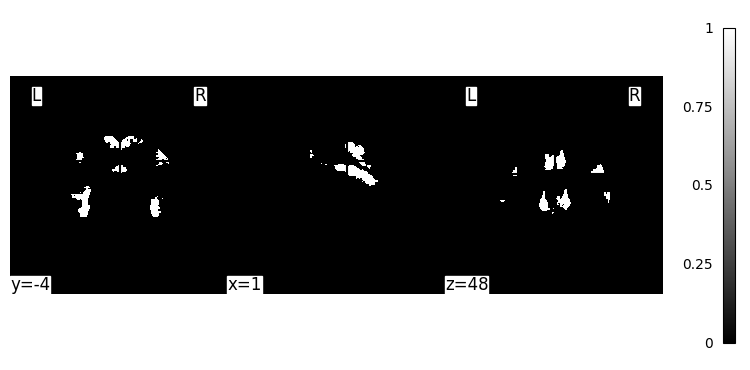

In [45]:
plot_img(salience_mask_3d)
show()

In [50]:
def cluster_salience_overlap(contrast_name, test=None):
    for sub_info in subjects_info:
        print(f"Subject {sub_info['subject_id']} - {sub_info['diagnosis']} - Cohort {sub_info['cohort']}\n")
        # Paths
        subject_path = os.path.join('..', 'Pediatric_Anxiety_Disorder', 'sub-'+sub_info['subject_id'], 'ses-1')
        func_path = os.path.join(subject_path, 'func')
        struct_path = os.path.join(subject_path, 'anat')
        run1_path = os.path.join(func_path, f'wrasub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-1_bold.nii')
        run2_path = os.path.join(func_path, f'wrasub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-2_bold.nii')
        mean_path = os.path.join(func_path, f'wmeanasub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-1_bold.nii')
        run1_events_path = os.path.join(func_path, f'sub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-1_events.tsv')
        run2_events_path = os.path.join(func_path, f'sub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-2_events.tsv')
        run1_confounds_path = os.path.join(func_path, f'rp_asub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-1_bold.txt')
        run2_confounds_path = os.path.join(func_path, f'rp_asub-{sub_info['subject_id']}_ses-1_task-TAU{sub_info['cohort']}_run-2_bold.txt')
        anat_path = os.path.join(struct_path, f'sub-{sub_info['subject_id']}_ses-1_T1w.nii')
        if sub_info['cohort']==1:
            rest_path = os.path.join(func_path, f'wrasub-{sub_info['subject_id']}_ses-1_task-rest_bold.nii')
            rest_confounds_path = os.path.join(func_path, f'rp_asub-{sub_info['subject_id']}_ses-1_task-rest_bold.txt')
        else:
            rest_echo1_path = os.path.join(func_path, f'wrasub-{sub_info['subject_id']}_ses-1_task-rest_echo-1_bold.nii')
            rest_echo1_confounds_path = os.path.join(func_path, f'rp_asub-{sub_info['subject_id']}_ses-1_task-rest_echo-1_bold.txt')
            rest_echo2_path = os.path.join(func_path, f'wrasub-{sub_info['subject_id']}_ses-1_task-rest_echo-2_bold.nii')
            rest_echo2_confounds_path = os.path.join(func_path, f'rp_asub-{sub_info['subject_id']}_ses-1_task-rest_echo-2_bold.txt')
            rest_echo3_path = os.path.join(func_path, f'wrasub-{sub_info['subject_id']}_ses-1_task-rest_echo-3_bold.nii')
            rest_echo3_confounds_path = os.path.join(func_path, f'rp_asub-{sub_info['subject_id']}_ses-1_task-rest_echo-3_bold.txt')
    
        # Loading images
        run1 = load_img(run1_path)
        run2 = load_img(run2_path)
        mean_fmri = load_img(mean_path)
        anat = load_img(anat_path)
        if sub_info['cohort']==1:
            rest = load_img(rest_path)
        else:
            rest_echo1 = load_img(rest_echo1_path)
            rest_echo2 = load_img(rest_echo2_path)
            rest_echo3 = load_img(rest_echo3_path)
        
        # Loading tables
        run1_events_table = pd.read_table(run1_events_path)[['onset','duration','trial_type']]
        run2_events_table = pd.read_table(run2_events_path)[['onset','duration','trial_type']]
        run1_confounds_table = pd.read_table(run1_confounds_path, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
        run2_confounds_table = pd.read_table(run2_confounds_path, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
        if sub_info['cohort']==1:
            rest_confounds_table = pd.read_table(rest_confounds_path, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
        else:
            rest_echo1_confounds_table = pd.read_table(rest_echo1_confounds_path, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
            rest_echo2_confounds_table = pd.read_table(rest_echo2_confounds_path, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
            rest_echo3_confounds_table = pd.read_table(rest_echo3_confounds_path, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
    
        
        # First-level GLM
        fl_glm = FirstLevelModel(
            t_r=TASK_TR,
            slice_time_ref=SLICE_TIME_REF,
            smoothing_fwhm=SMOOTHING,
            hrf_model=HRF_MODEL,
            drift_model=DRIFT_MODEL,
            high_pass=HIGH_PASS,
            standardize=STANDARDIZE,
            n_jobs=-1
        )
    
        fl_glm.fit([run1, run2], 
                   events=[run1_events_table, run2_events_table],
                   confounds=[run1_confounds_table, run2_confounds_table]
                  )
    
        # Incongruent vs Congruent Contrast testing
        contrast_outputs = fl_glm.compute_contrast(
            contrast_def=CONTRASTS[contrast_name],
            stat_type='t',
            output_type='all'
        )
    
        clean_z_map, threshold_z = threshold_stats_img(
            contrast_outputs['z_score'],
            alpha=ALPHA,
            height_control=HEIGHT_CONTROL,
            two_sided=False
        )
    
        plotting_config = {
            'bg_img': mean_fmri,
            'cmap': 'inferno',
            'black_bg': True
        }
        
        if test:
            testing = test
        else:
            testing = contrast_name
    
        plot_stat_map(
            clean_z_map,
            threshold=threshold_z,
            title=f"Subject {sub_info['subject_id']} - {testing} (p<{ALPHA}; threshold={threshold_z:.3f})",
            figure=plt.figure(figsize=(10,4)),
            **plotting_config
        )
        show()
    
        # Clusters/ROIs Map
        cluster_table, ROI_map = get_clusters_table(
            stat_img=clean_z_map,
            stat_threshold=threshold_z,
            cluster_threshold=0,
            two_sided=False,
            return_label_maps=True
        )
        ROI_map = ROI_map[0]
        print(f"Subject {sub_info['subject_id']} - Number of ROIs found in {testing}: {len(np.unique(ROI_map.get_fdata())) - 1}")

        # Resample salience mask
        salience_resampled = resample_to_img(salience_mask_3d, ROI_map, interpolation='nearest')

        overlap_img = math_img("np.logical_and(img1 > 0, img2 > 0)", 
                               img1=ROI_map, img2=salience_resampled)

        # Overlap Volume
        voxel_size = np.prod(ROI_map.header.get_zooms())
        overlap_voxels = np.sum(overlap_img.get_fdata())
        overlap_volume = overlap_voxels * voxel_size
        print(f"Overlap Volume with Salience Network: {overlap_volume:.2f} mm3")
        if overlap_voxels>0:
            plot_roi(overlap_img,
                     bg_img=mean_fmri,
                     title='Salience x Task Cluster Overlap')
            show()
        # Overlap Percentage
        total_roi_voxels = np.sum(ROI_map.get_fdata() > 0)
        overlap_voxels = np.sum(overlap_img.get_fdata() > 0)
        if total_roi_voxels > 0:
            overlap_percentage = (overlap_voxels / total_roi_voxels) * 100
        else:
            overlap_percentage = 0

        print(f"Subject {sub_info['subject_id']} - Overlap: {overlap_percentage:.2f}% of task clusters are in the Salience Network\n\n")
        

Subject 20131 - Healthy - Cohort 1



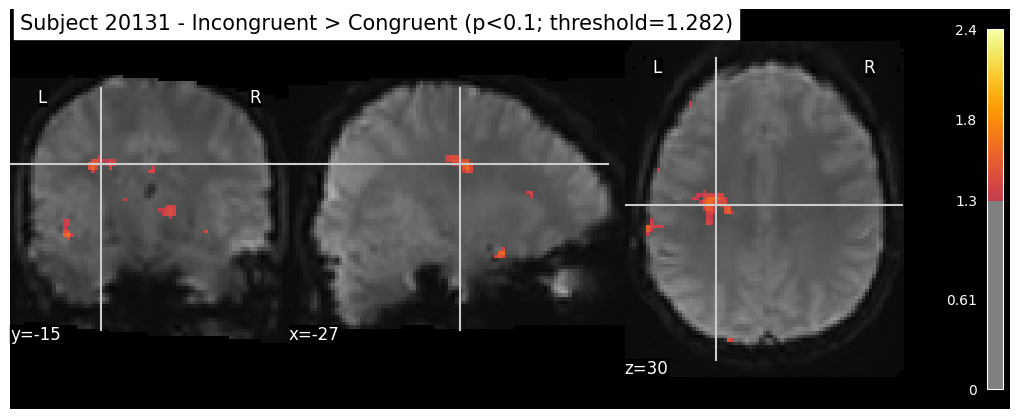

Subject 20131 - Number of ROIs found in Incongruent > Congruent: 67
Overlap Volume with Salience Network: 816.00 mm3


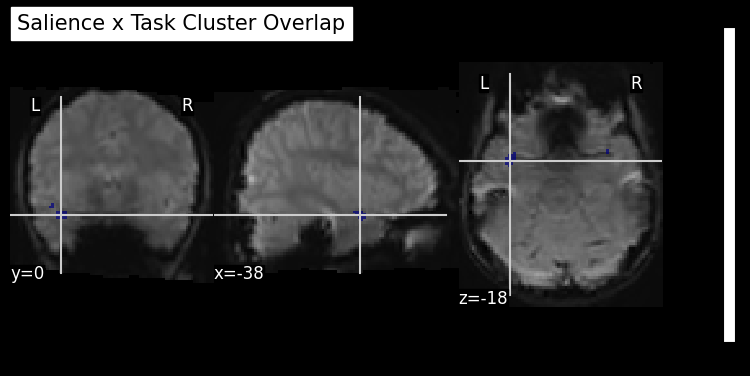

Subject 20131 - Overlap: 10.77% of task clusters are in the Salience Network


Subject 22286 - Anxiety - Cohort 1



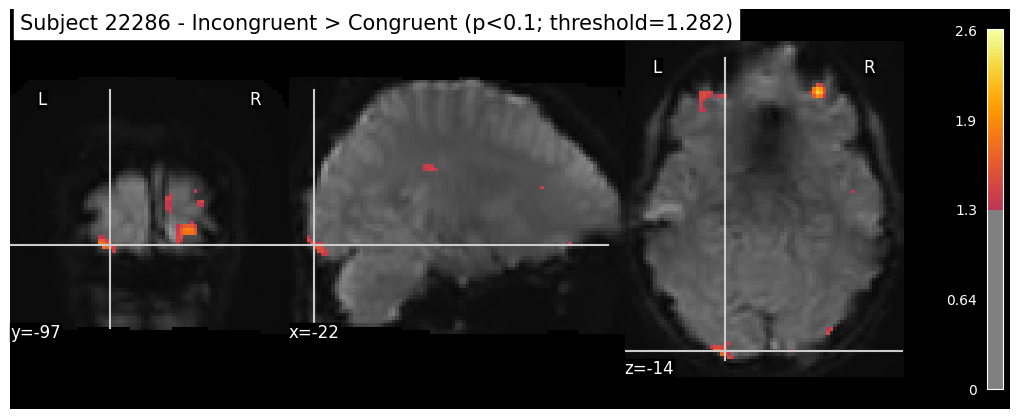

Subject 22286 - Number of ROIs found in Incongruent > Congruent: 76
Overlap Volume with Salience Network: 120.00 mm3


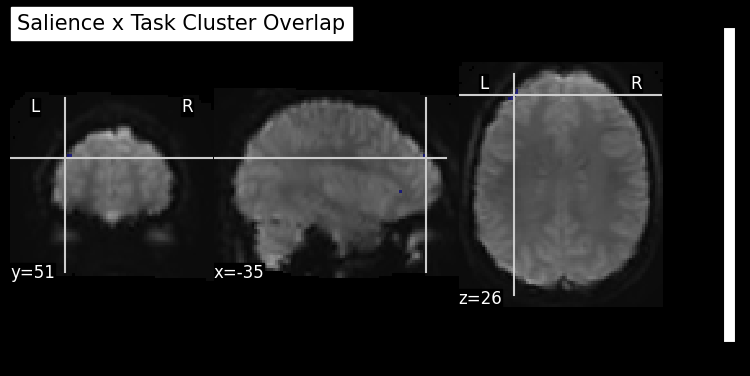

Subject 22286 - Overlap: 1.68% of task clusters are in the Salience Network


Subject 23842 - Anxiety - Cohort 2



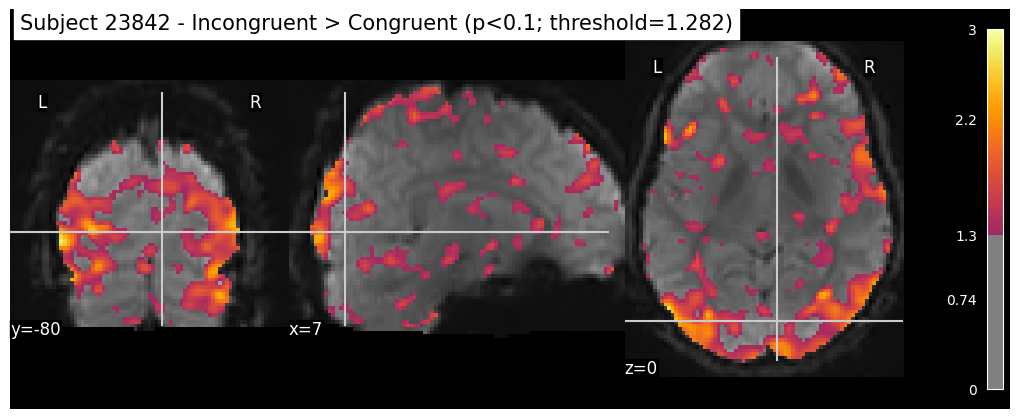

Subject 23842 - Number of ROIs found in Incongruent > Congruent: 215
Overlap Volume with Salience Network: 20384.00 mm3


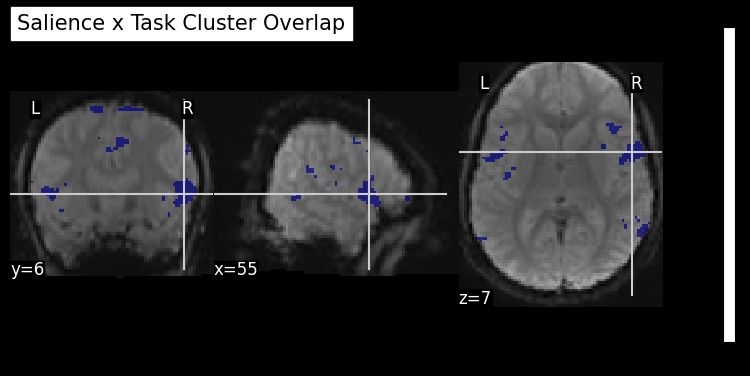

Subject 23842 - Overlap: 4.93% of task clusters are in the Salience Network


Subject 24050 - Healthy - Cohort 2



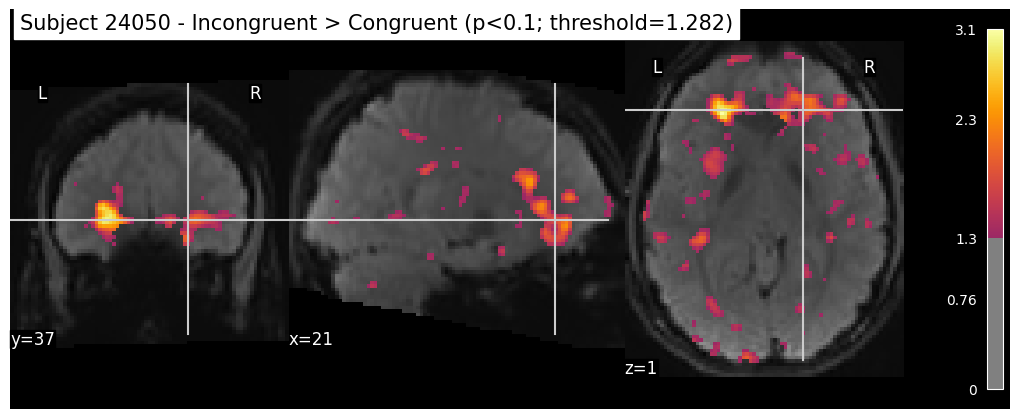

Subject 24050 - Number of ROIs found in Incongruent > Congruent: 209
Overlap Volume with Salience Network: 4448.00 mm3


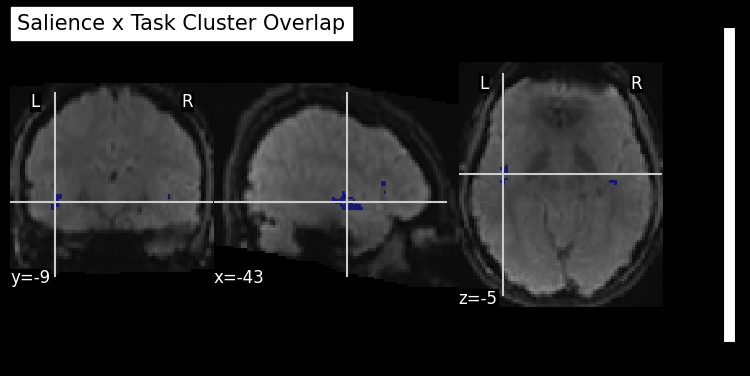

Subject 24050 - Overlap: 7.25% of task clusters are in the Salience Network




In [51]:
cluster_salience_overlap('incongruent_vs_congruent', 'Incongruent > Congruent')

Subject 20131 - Healthy - Cohort 1



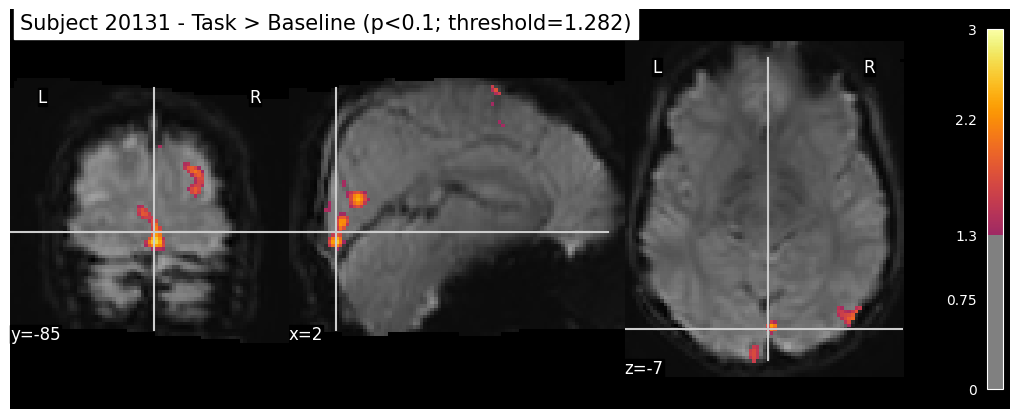

Subject 20131 - Number of ROIs found in Task > Baseline: 31
Overlap Volume with Salience Network: 736.00 mm3


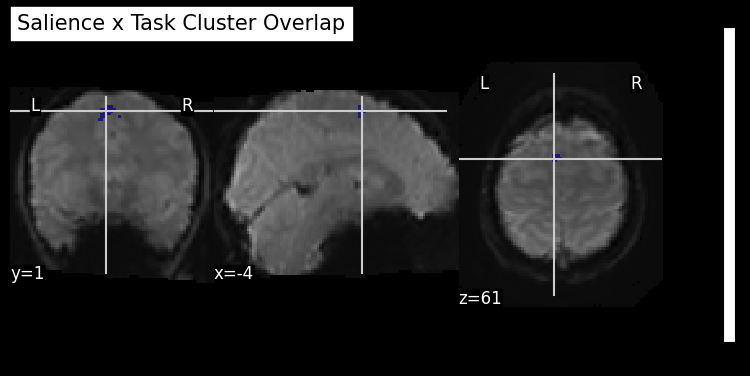

Subject 20131 - Overlap: 5.82% of task clusters are in the Salience Network


Subject 22286 - Anxiety - Cohort 1



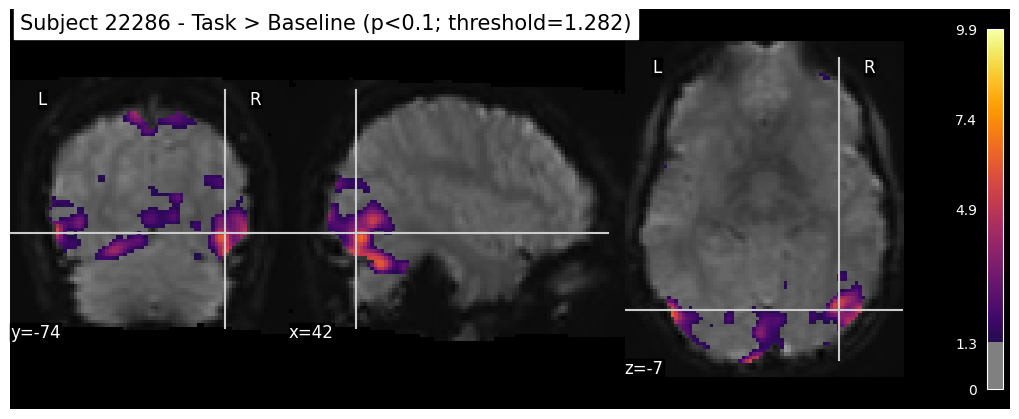

Subject 22286 - Number of ROIs found in Task > Baseline: 119
Overlap Volume with Salience Network: 1400.00 mm3


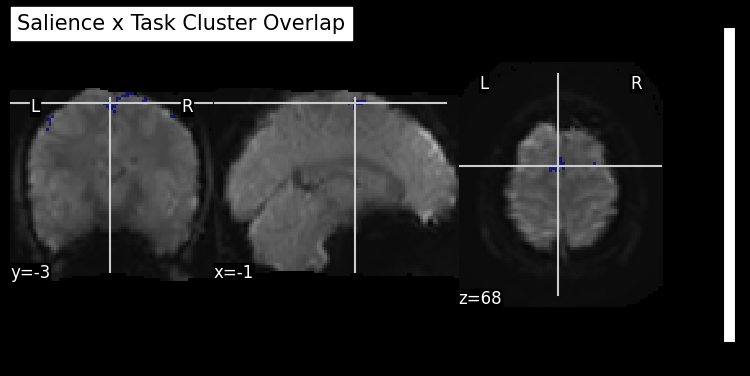

Subject 22286 - Overlap: 1.69% of task clusters are in the Salience Network


Subject 23842 - Anxiety - Cohort 2



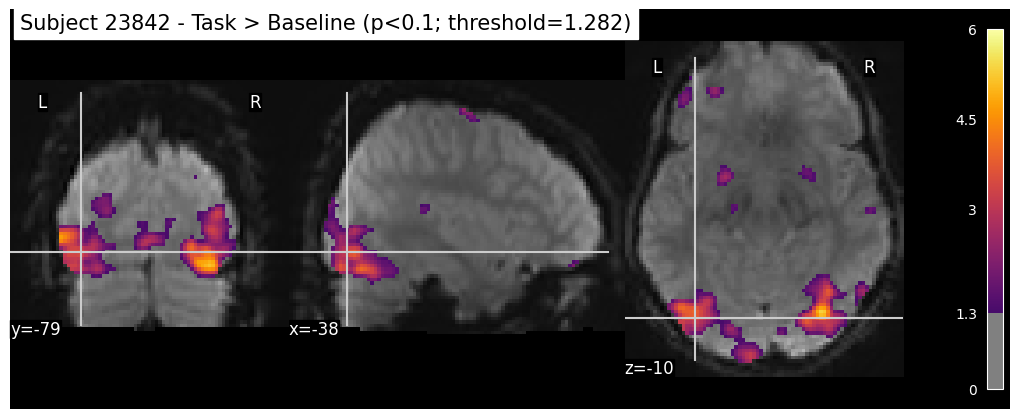

Subject 23842 - Number of ROIs found in Task > Baseline: 117
Overlap Volume with Salience Network: 1480.00 mm3


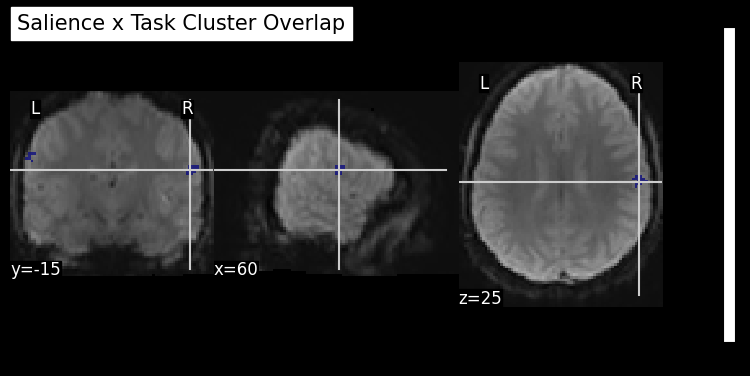

Subject 23842 - Overlap: 1.76% of task clusters are in the Salience Network


Subject 24050 - Healthy - Cohort 2



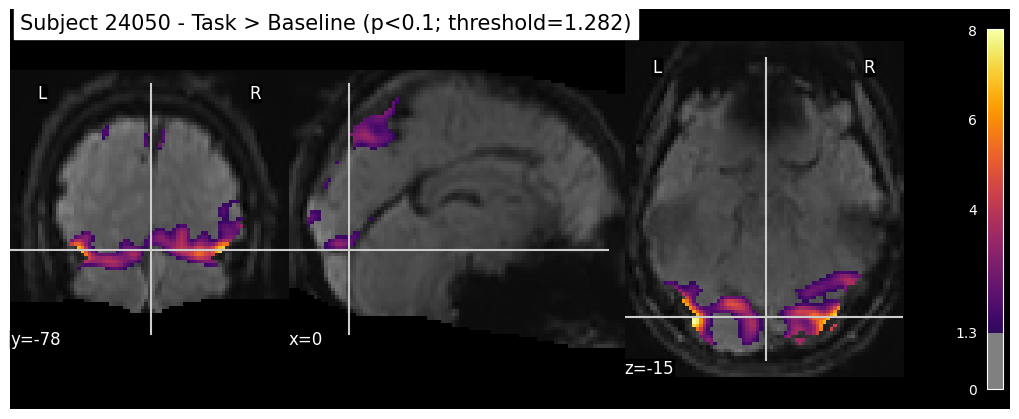

Subject 24050 - Number of ROIs found in Task > Baseline: 70
Overlap Volume with Salience Network: 0.00 mm3
Subject 24050 - Overlap: 0.00% of task clusters are in the Salience Network




In [52]:
cluster_salience_overlap('task_vs_baseline', 'Task > Baseline')